- 線形attention
- すべてのパラメータを学習するが正則化をつける
- Mを固定したまま異なるNの効果を検証


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ===== 実験設定（M固定・N可変） =====
D = 10
FIXED_M = 10000
BATCH_SIZE = 1000
ADAM_LR = 1e-3
PARAM_L2_LAMBDA = 0.1
ITERATIONS = 4000
EVAL_K_LIST = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
SEED = 420

# 複数 N を比較
N_LIST = [40, 60, 80, 120, 160]

# 固定条件
W0_INIT_MODE = "random"
TRAINING_MODE = "no_cot"

DE = 2 * D + 2
INIT_SCALE = 0.1
LSA_OUTPUT_GAIN = 1.0 / np.sqrt(DE)  # softmax.ipynb と同様のスケーリング方針

np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(
    f"device={device}, d={D}, M={FIXED_M}, B={BATCH_SIZE}, iters={ITERATIONS}, "
    f"w0={W0_INIT_MODE}, mode={TRAINING_MODE}, l2={PARAM_L2_LAMBDA}, "
    f"init_scale={INIT_SCALE}, out_gain={LSA_OUTPUT_GAIN:.4f}, N_LIST={N_LIST}"
)


device=cpu, d=10, M=10000, B=300, iters=4000, w0=random, mode=no_cot, l2=0.1, init_scale=0.1, out_gain=0.2132, N_LIST=[40, 60, 80, 120, 160]


In [62]:
def sample_task_batch(batch_size, n, d=D, device=device):
    X = torch.randn(batch_size, d, n, device=device)
    w_star = torch.randn(batch_size, d, device=device)
    y = torch.einsum("bd,bdn->bn", w_star, X) 
    return X, y, w_star


def build_fixed_train_dataset(M, n):
    X, y, w_star = sample_task_batch(M, n)
    return {"X": X, "y": y, "w_star": w_star, "M": M, "n": n}


def sample_train_minibatch(train_data, batch_size=BATCH_SIZE):
    # 復元抽出（同じデータが複数回選ばれうる）
    idx = torch.randint(0, train_data["M"], (batch_size,), device=device)
    return train_data["X"][idx], train_data["y"][idx], train_data["w_star"][idx]


def sample_w0_random(X, d=D, device=device):
    return torch.randn(X.shape[0], d, device=device)


def build_Z(X, y, w_prefix):
    B, d, n = X.shape
    i = len(w_prefix) - 1
    L = n + i + 1
    Z = torch.zeros(B, DE, L, device=X.device)
    Z[:, :d, :n] = X
    Z[:, d, :n] = y
    for t, w_t in enumerate(w_prefix):
        Z[:, d + 1 : d + 1 + d, n + t] = w_t
    Z[:, -1, :] = 1.0
    return Z


def f_lsa_last(Z, V, W, n, output_gain=LSA_OUTPUT_GAIN):
    z_last = Z[:, :, -1]
    Wz = torch.einsum("ij,bj->bi", W, z_last)
    scores = torch.einsum("bjl,bj->bl", Z, Wz) / n
    weighted = torch.einsum("bjl,bl->bj", Z, scores)
    out_last = z_last + output_gain * torch.einsum("ij,bj->bi", V, weighted)
    return out_last


def no_cot_train_loss(V, W, X, y, w_star):
    n = X.shape[2]
    w0 = sample_w0_random(X, D, X.device)
    Z0 = build_Z(X, y, [w0])
    pred = f_lsa_last(Z0, V, W, n=n)
    target = torch.zeros_like(pred)
    target[:, D + 1 : D + 1 + D] = w_star
    target[:, -1] = 1.0
    return 0.5 * ((pred - target) ** 2).sum(dim=1).mean()


def eval_loss(V, W, k_eval, n, batch_size=4000):
    X, y, w_star = sample_task_batch(batch_size, n)
    with torch.no_grad():
        # softmax.ipynb と同様: 推論のみ w0=0、k=0 は 0 ベクトルをそのまま評価
        w0 = torch.zeros(batch_size, D, device=device)
        w_prefix = [w0]
        for _ in range(k_eval):
            Z = build_Z(X, y, w_prefix)
            pred = f_lsa_last(Z, V, W, n=n)
            w_hat = pred[:, D + 1 : D + 1 + D]
            w_prefix.append(w_hat)

        w_hat_final = w_prefix[-1]
        loss = ((w_hat_final - w_star) ** 2).mean(dim=1).mean().item()
    return loss


def parameter_l2_penalty(V, W):
    return V.pow(2).sum() + W.pow(2).sum()


def train_model_no_cot_finite(train_data, iterations=ITERATIONS, log_every=20):
    n = train_data["n"]
    V = nn.Parameter(INIT_SCALE * torch.randn(DE, DE, device=device))
    W = nn.Parameter(INIT_SCALE * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([V, W], lr=ADAM_LR)

    eval_curve = []
    for t in range(iterations):
        X, y, w_star = sample_train_minibatch(train_data, BATCH_SIZE)
        data_loss = no_cot_train_loss(V, W, X, y, w_star)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(V, W)
        loss = data_loss + reg_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if t % log_every == 0:
            eval_curve.append(eval_loss(V, W, k_eval=0, n=n))

    return V.detach(), W.detach(), np.array(eval_curve)


In [63]:
assert TRAINING_MODE == "no_cot"
assert W0_INIT_MODE == "random"

results_by_N = {}

for N_var in N_LIST:
    print(f"\n=== training with fixed M={FIXED_M}, N={N_var} ===")
    train_data = build_fixed_train_dataset(FIXED_M, N_var)
    V_tr, W_tr, train_curve = train_model_no_cot_finite(train_data, iterations=ITERATIONS)

    final_eval = {}
    for k_eval in EVAL_K_LIST:
        final_eval[k_eval] = eval_loss(V_tr, W_tr, k_eval=k_eval, n=N_var)
    results_by_N[N_var] = {
        "final_eval": final_eval,
        "train_curve": train_curve,
    }

    for k_eval in EVAL_K_LIST:
        print(f"N={N_var:>4}, k_eval={k_eval:>2}: {final_eval[k_eval]:.6f}")



=== training with fixed M=10000, N=40 ===
N=  40, k_eval= 0: 0.990413
N=  40, k_eval= 1: 0.245070
N=  40, k_eval= 2: 0.240372
N=  40, k_eval= 3: 0.463282
N=  40, k_eval= 4: 0.748641
N=  40, k_eval= 5: 0.988355
N=  40, k_eval= 6: 1.217928
N=  40, k_eval= 7: 1.400835
N=  40, k_eval= 8: 1.590761
N=  40, k_eval= 9: 1.725108
N=  40, k_eval=10: 1.886014
N=  40, k_eval=11: 2.011870
N=  40, k_eval=12: 2.106351
N=  40, k_eval=13: 2.166878
N=  40, k_eval=14: 2.247656
N=  40, k_eval=15: 2.346764
N=  40, k_eval=16: 2.436136
N=  40, k_eval=17: 2.418988
N=  40, k_eval=18: 2.506351
N=  40, k_eval=19: 2.526046
N=  40, k_eval=20: 2.587521

=== training with fixed M=10000, N=60 ===
N=  60, k_eval= 0: 0.990570
N=  60, k_eval= 1: 0.187938
N=  60, k_eval= 2: 0.200980
N=  60, k_eval= 3: 0.460827
N=  60, k_eval= 4: 0.795001
N=  60, k_eval= 5: 1.090802
N=  60, k_eval= 6: 1.375897
N=  60, k_eval= 7: 1.601248
N=  60, k_eval= 8: 1.817468
N=  60, k_eval= 9: 1.959857
N=  60, k_eval=10: 2.100063
N=  60, k_eval=11:

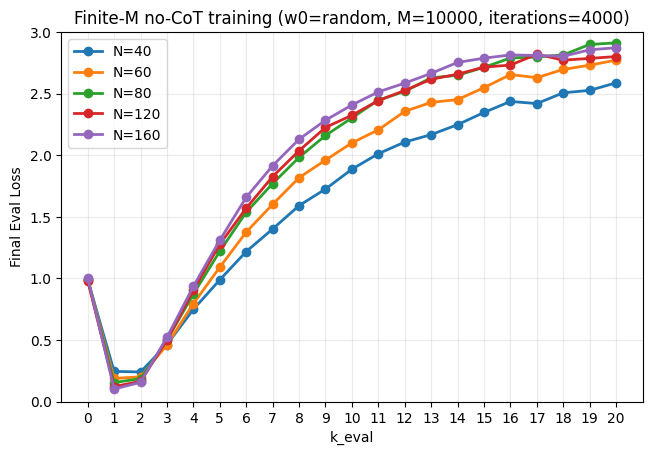

In [64]:
# N ごとの結果を重ね描き
plt.figure(figsize=(7.5, 4.8))
for N_var in N_LIST:
    ks = np.array(sorted(results_by_N[N_var]["final_eval"].keys()))
    vals = np.array([results_by_N[N_var]["final_eval"][k] for k in ks])
    plt.plot(ks, vals, marker="o", linewidth=2, label=f"N={N_var}")

plt.xlabel("k_eval")
plt.ylabel("Final Eval Loss")
plt.title(f"Finite-M no-CoT training (w0=random, M={FIXED_M}, iterations={ITERATIONS})")
plt.xticks(EVAL_K_LIST)
plt.ylim(0, 3.0)
plt.grid(alpha=0.25)
plt.legend()
plt.show()
